# Bob's Conundrum — Store 10 Performance Analysis

*Companion notebook for IPADE case AD 23 eC 02.*

**The question:** Is Store 10 a good performer?

**The trap Bob fell into:** he compared Store 10's averages to the dataset's averages, saw *"above average"*, and called it a good store. He missed the trend sitting in his own Table 3 — Store 10's weekly sales were **declining while all its peers were growing**.

**The reframe:** "Good" only has meaning relative to (a) a peer group, (b) a metric, and (c) a horizon. This notebook runs a 5-layer analysis:

| Layer | Question |
|-------|----------|
| 1. Define | Peer group? Metric? Horizon? |
| 2. Describe | Normalize (per sqft), trend, seasonality, distribution |
| 3. Benchmark | Percentile rank within relevant peer groups |
| 4. Explain | Regression — does context explain Store 10, or does Store 10 beat context? |
| 5. Recommend | Headline verdict + supporting evidence |

**Data source:** Kaggle — [Walmart Sales Forecast](https://www.kaggle.com/datasets/aslanahmedov/walmart-salesforecast). Place `stores.csv`, `features.csv`, and `sales.csv` in the same directory as this notebook before running.

## 1. Imports and setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

## 2. Load and clean the data

Three things need handling for the raw Kaggle files:
- Dates arrive as ISO strings (`YYYY-MM-DD`).
- `IsHoliday` arrives as string literals `"TRUE"`/`"FALSE"`, not booleans.
- `features.csv` includes `MarkDown1`–`MarkDown5` columns that are mostly null before November 2011. We load them but don't use them as regression inputs here (they'd need careful imputation).

In [2]:
sales    = pd.read_csv('sales.csv')
stores   = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

# Dates
sales['Date']    = pd.to_datetime(sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Booleans
bool_map = {'TRUE': True, 'FALSE': False, True: True, False: False}
sales['IsHoliday']    = sales['IsHoliday'].map(bool_map)
features['IsHoliday'] = features['IsHoliday'].map(bool_map)

print(f"sales:    {sales.shape[0]:>7,} rows | {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"stores:   {stores.shape[0]:>7,} rows")
print(f"features: {features.shape[0]:>7,} rows")
print(f"\nStore 10: Type {stores.loc[stores['Store']==10,'Type'].values[0]}, "
      f"{stores.loc[stores['Store']==10,'Size'].values[0]:,} sqft")

sales:    421,570 rows | 2010-02-05 → 2012-10-26
stores:        45 rows
features:   8,190 rows

Store 10: Type B, 126,512 sqft


### Sanity check — reproduce Bob's Exhibit B

If our data load is correct, we should replicate Bob's own tables exactly. This catches schema errors before they propagate into the analysis.

In [3]:
sales['Year'] = sales['Date'].dt.year

print("Bob's Table 3 (avg weekly sales at row level) — case vs. reproduced:")
s10_avg = sales[sales['Store']==10].groupby('Year')['Weekly_Sales'].mean().round(0)
all_avg = sales.groupby('Year')['Weekly_Sales'].mean().round(0)
print(f"  Store 10 — case:       26984 / 26399 / 25507")
print(f"  Store 10 — reproduced: {s10_avg[2010]:.0f} / {s10_avg[2011]:.0f} / {s10_avg[2012]:.0f}")
print(f"  All — case:            16270 / 15954 / 15695")
print(f"  All — reproduced:      {all_avg[2010]:.0f} / {all_avg[2011]:.0f} / {all_avg[2012]:.0f}")

f10 = features[features['Store']==10][['Temperature','Fuel_Price','CPI','Unemployment']].mean()
print(f"\nBob's Table 2 (Store 10 regional avgs):")
print(f"  Temp {f10['Temperature']:.1f} | Fuel {f10['Fuel_Price']:.2f} | "
      f"CPI {f10['CPI']:.0f} | Unemp {f10['Unemployment']:.2f}")
print("  Case values:        71   | 3.62       | 129      | 8.14")

Bob's Table 3 (avg weekly sales at row level) — case vs. reproduced:
  Store 10 — case:       26984 / 26399 / 25507
  Store 10 — reproduced: 26984 / 26399 / 25507
  All — case:            16270 / 15954 / 15695
  All — reproduced:      16270 / 15954 / 15695

Bob's Table 2 (Store 10 regional avgs):
  Temp 71.3 | Fuel 3.62 | CPI 129 | Unemp 8.14
  Case values:        71   | 3.62       | 129      | 8.14


### Merge and aggregate

Build two working tables:
- `df` — store-dept-week grain (421,570 rows)
- `sw` — store-week grain, weekly sales summed across departments. Most strategic questions live at the store level.

In [4]:
df = sales.merge(stores, on='Store').merge(
    features.drop(columns=['IsHoliday']), on=['Store','Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['SalesPerSqFt'] = df['Weekly_Sales'] / df['Size']

sw = df.groupby(['Store','Date','Type','Size','Year','Month',
                 'Temperature','Fuel_Price','CPI','Unemployment',
                 'IsHoliday'], as_index=False)['Weekly_Sales'].sum()
sw['SalesPerSqFt'] = sw['Weekly_Sales'] / sw['Size']

print(f"Master table (store-dept-week): {len(df):>7,} rows")
print(f"Store-week aggregate:           {len(sw):>7,} rows "
      f"({df['Store'].nunique()} stores × {df['Date'].nunique()} weeks)")

Master table (store-dept-week): 421,570 rows
Store-week aggregate:             6,435 rows (45 stores × 143 weeks)


## Layer 1 — Define the question

Before touching the data, pin down three things:

**Metric palette** (each rewards a different quality):
- Absolute weekly sales → rewards bigness
- Sales per sqft → rewards productivity
- YoY growth → rewards momentum
- Holiday lift → rewards event execution
- Volatility (CV) → rewards consistency

**Peer groups** (in order of increasing rigor):
- All 45 stores — Bob's naive benchmark
- Same Type (A/B/C) — the right first-order peer group
- Similar size ±15% — tightest comparable set

**Horizon:** levels (today), trends (direction), volatility (reliability).

Bob picked one cell of this 5×3 grid: absolute levels, all stores, ignoring horizon. Let's fill in the rest.

**Important note on the 2012 data:** the dataset ends 2012-10-26, so calendar-year 2012 is incomplete (only 10 of 12 months). For growth comparisons we use a Feb–Oct window in both years to avoid a seasonal apples-to-oranges artifact.

## Layer 2 — Describe

### 2a. Trend: Store 10 vs. Type-B peers vs. everyone else

Store-level weekly sales (summed across departments) by year.

In [5]:
annual = sw.groupby(['Store','Year'], as_index=False).agg(
    AvgWeeklyStoreSales=('Weekly_Sales','mean'),
    SalesPerSqFt=('SalesPerSqFt','mean'),
).merge(stores[['Store','Type']], on='Store')

s10_annual  = annual[annual['Store']==10].set_index('Year')
typeB_nons10 = annual[(annual['Type']=='B') & (annual['Store']!=10)].groupby('Year').mean(numeric_only=True)
others_annual = annual[annual['Store']!=10].groupby('Year').mean(numeric_only=True)

trend = pd.DataFrame({
    'Store 10 — weekly':      s10_annual['AvgWeeklyStoreSales'],
    'Type-B peers — weekly':  typeB_nons10['AvgWeeklyStoreSales'],
    'All others — weekly':    others_annual['AvgWeeklyStoreSales'],
    'Store 10 — $/sqft':      s10_annual['SalesPerSqFt'],
    'Type-B peers — $/sqft':  typeB_nons10['SalesPerSqFt'],
    'All others — $/sqft':    others_annual['SalesPerSqFt'],
})
trend.round(2)

,Store 10 — weekly,Type-B peers — weekly,All others — weekly,Store 10 — $/sqft,Type-B peers — $/sqft,All others — $/sqft
Year,,,,,,
2010,1968170.88,775397.83,1039021.74,15.56,8.06,8.42
2011,1902247.98,751444.84,1026784.58,15.04,7.90,8.31
2012,1819270.16,738917.71,1015805.62,14.38,7.83,8.30


### 2b. Growth — using comparable Feb–Oct windows

Because 2012 only extends to October 26, we measure growth on the matched Feb 5 – Oct 26 window each year. This eliminates seasonal distortion.

In [6]:
def window_avg(dfx, year, start='02-05', end='10-26'):
    mask = (dfx['Year']==year) & (dfx['Date'] >= f'{year}-{start}') & (dfx['Date'] <= f'{year}-{end}')
    return dfx[mask].groupby('Store')['Weekly_Sales'].mean()

g2010 = window_avg(sw, 2010)
g2012 = window_avg(sw, 2012)
growth = ((g2012 / g2010) - 1) * 100

typeB_stores = stores[stores['Type']=='B']['Store'].tolist()
typeB_peers_ex10 = [s for s in typeB_stores if s != 10]

print("Growth Feb–Oct 2010 → Feb–Oct 2012:")
print(f"  Store 10:                   {growth.loc[10]:+.2f}%")
print(f"  Type-B peers median:        {growth.loc[typeB_peers_ex10].median():+.2f}%")
print(f"  Type-B peers mean:          {growth.loc[typeB_peers_ex10].mean():+.2f}%")
print(f"  All-others median:          {growth.loc[growth.index!=10].median():+.2f}%")
print(f"  N Type-B peers growing:     {(growth.loc[typeB_peers_ex10] > 0).sum()} / {len(typeB_peers_ex10)}")
print(f"\nStore 10 is the ONLY direction (if any) where the signs diverge.")

Growth Feb–Oct 2010 → Feb–Oct 2012:
  Store 10:                   -2.14%
  Type-B peers median:        +2.32%
  Type-B peers mean:          +2.49%
  All-others median:          +3.27%
  N Type-B peers growing:     10 / 16

Store 10 is the ONLY direction (if any) where the signs diverge.


### 2c. Holiday sensitivity

Does Store 10 execute well on holiday weeks?

In [7]:
hol = sw.groupby(['Store','IsHoliday'])['Weekly_Sales'].mean().unstack()
hol['Lift'] = (hol[True] / hol[False] - 1) * 100

print(f"Holiday lift:")
print(f"  Store 10:              {hol.loc[10,'Lift']:+.1f}%")
print(f"  Type-B peers mean:     {hol.loc[typeB_peers_ex10,'Lift'].mean():+.1f}%")
print(f"  All others mean:       {hol.loc[hol.index!=10,'Lift'].mean():+.1f}%")
print(f"\nStore 10 executes better on holidays than its peers — a point in its favor.")

Holiday lift:
  Store 10:              +12.2%
  Type-B peers mean:     +10.9%
  All others mean:       +7.3%

Store 10 executes better on holidays than its peers — a point in its favor.


### 2d. Volatility

Coefficient of variation (std/mean) — lower is more consistent week-to-week.

In [8]:
vol = sw.groupby('Store')['Weekly_Sales'].agg(['mean','std'])
vol['CV'] = vol['std'] / vol['mean']

print(f"CV — Store 10:              {vol.loc[10,'CV']:.3f}")
print(f"CV — Type-B peers median:   {vol.loc[typeB_peers_ex10,'CV'].median():.3f}")
print(f"CV — All others median:     {vol.loc[vol.index!=10,'CV'].median():.3f}")

CV — Store 10:              0.159
CV — Type-B peers median:   0.164
CV — All others median:     0.129


## Layer 3 — Benchmark

Percentile ranks in three progressively tighter peer groups. If the answer is sensitive to peer group choice, the peer group *is* the insight.

In [9]:
store_metrics = sw.groupby('Store').agg(
    AvgWeekly=('Weekly_Sales','mean'),
    SalesPerSqFt=('SalesPerSqFt','mean'),
).merge(stores, on='Store')
store_metrics['Growth'] = growth.reindex(store_metrics['Store']).values

size10 = 126512

rank_rows = []
for name, grp in [('All 45 stores', store_metrics),
                  ('Type-B peers', store_metrics[store_metrics['Type']=='B']),
                  ('Similar size (±15%)', store_metrics[
                      (store_metrics['Size'] >= size10*0.85) &
                      (store_metrics['Size'] <= size10*1.15)])]:
    s = grp.set_index('Store')
    rank_rows.append({
        'Peer group':     f"{name} (n={len(grp)})",
        'Abs sales pct':  s['AvgWeekly'].rank(pct=True).loc[10]*100,
        '$/sqft pct':     s['SalesPerSqFt'].rank(pct=True).loc[10]*100,
        'Growth pct':     s['Growth'].rank(pct=True).loc[10]*100,
    })
rank_df = pd.DataFrame(rank_rows).set_index('Peer group').round(1)
rank_df

,Abs sales pct,$/sqft pct,Growth pct
Peer group,,,
All 45 stores (n=45),88.9,97.8,28.9
Type-B peers (n=17),100.0,100.0,29.4
Similar size (±15%) (n=10),100.0,100.0,40.0


**The table that nails the teaching point.** Store 10's rank on *level* and *productivity* is at the top across every peer cut. But its *growth* rank is bottom-third — and the divergence is structural, not a peer-group artifact. This is the level-vs-momentum split that Bob's averages buried.

## Layer 4 — Explain

*Does Store 10 beat its context, or is it simply riding it?*

We fit an OLS on the other 44 stores relating `log(Weekly_Sales)` to size, type, and regional controls. The coefficients tell us what a "typical" store in a given context produces. Store 10's **residual** — actual minus predicted — measures its genuine context-adjusted outperformance.

Tracking the residual *over time* tells us whether the edge is growing, stable, or eroding.

In [10]:
model_df = sw.copy()
model_df['LogSales'] = np.log(model_df['Weekly_Sales'])
model_df['LogSize']  = np.log(model_df['Size'])
model_df['IsHol']    = model_df['IsHoliday'].astype(int)

model = smf.ols(
    'LogSales ~ LogSize + C(Type) + CPI + Unemployment + Temperature + Fuel_Price + IsHol',
    data=model_df[model_df['Store'] != 10]
).fit()
print(model.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.5799      0.107     33.556      0.000       3.371       3.789
C(Type)[T.B]    -0.0653      0.009     -7.397      0.000      -0.083      -0.048
C(Type)[T.C]     0.2528      0.016     16.230      0.000       0.222       0.283
LogSize          0.8830      0.008    107.273      0.000       0.867       0.899
CPI             -0.0002   9.49e-05     -1.829      0.068      -0.000    1.25e-05
Unemployment    -0.0113      0.002     -5.864      0.000      -0.015      -0.008
Temperature      0.0002      0.000      1.018      0.309      -0.000       0.001
Fuel_Price      -0.0159      0.008     -2.088      0.037      -0.031      -0.001
IsHol            0.0617      0.013      4.625      0.000       0.036       0.088


In [11]:
s10_data = model_df[model_df['Store']==10].copy()
s10_data['Predicted_Sales']  = np.exp(model.predict(s10_data))
s10_data['Pct_Above_Model']  = (s10_data['Weekly_Sales']/s10_data['Predicted_Sales'] - 1)*100

print(f"Store 10 mean actual weekly sales:    ${s10_data['Weekly_Sales'].mean():>12,.0f}")
print(f"Store 10 mean model-predicted sales:   ${s10_data['Predicted_Sales'].mean():>12,.0f}")
print(f"Mean outperformance vs. model:         {s10_data['Pct_Above_Model'].mean():>+12.1f}%")
print(f"\nOutperformance by year:")
print(s10_data.groupby('Year')['Pct_Above_Model'].mean().round(1))
print(f"\nStore 10's context-adjusted edge is eroding roughly 8–9 pp/year.")

Store 10 mean actual weekly sales:    $   1,899,425
Store 10 mean model-predicted sales:   $     920,398
Mean outperformance vs. model:               +106.4%

Outperformance by year:
Year
2010    114.1
2011    107.0
2012     96.9
Name: Pct_Above_Model, dtype: float64

Store 10's context-adjusted edge is eroding roughly 8–9 pp/year.


## Layer 5 — Visual story

Four panels, one screen, whole narrative:
- **A.** Quarterly trend — visualizes Store 10 declining while peers hold/grow
- **B.** Percentile ranks — level vs. growth gap across peer groups
- **C.** Productivity distribution — places Store 10 as a far outlier within Type B
- **D.** Residual over time — the erosion of the context-adjusted edge

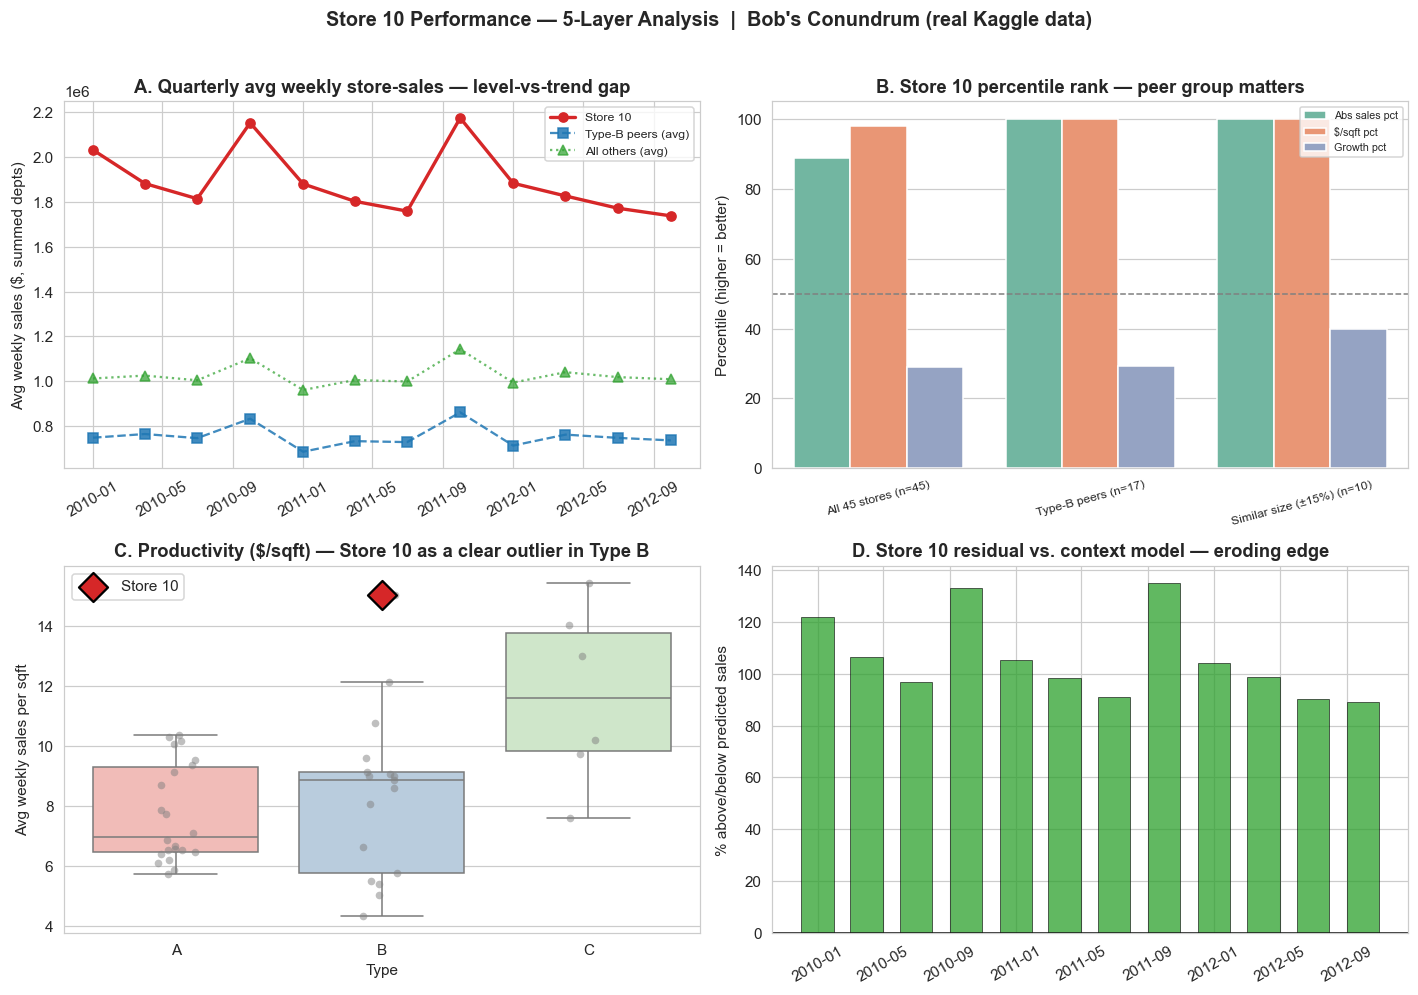

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: quarterly trend
ax = axes[0,0]
tp = sw.groupby([sw['Date'].dt.to_period('Q'),'Store'])['Weekly_Sales'].mean().reset_index()
tp['Date'] = tp['Date'].dt.to_timestamp()
tp = tp.merge(stores[['Store','Type']], on='Store')
s10q = tp[tp['Store']==10]
tBq  = tp[(tp['Type']=='B') & (tp['Store']!=10)].groupby('Date')['Weekly_Sales'].mean()
restq = tp[tp['Store']!=10].groupby('Date')['Weekly_Sales'].mean()
ax.plot(s10q['Date'], s10q['Weekly_Sales'], 'o-', lw=2.2, color='#d62728', label='Store 10')
ax.plot(tBq.index, tBq.values, 's--', color='#1f77b4', alpha=0.85, label='Type-B peers (avg)')
ax.plot(restq.index, restq.values, '^:', color='#2ca02c', alpha=0.7, label='All others (avg)')
ax.set_title('A. Quarterly avg weekly store-sales — level-vs-trend gap', fontweight='bold')
ax.set_ylabel('Avg weekly sales ($, summed depts)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

# Panel B: percentile ranks
ax = axes[0,1]
rp = rank_df.reset_index().melt(id_vars='Peer group',
    value_vars=['Abs sales pct','$/sqft pct','Growth pct'],
    var_name='Metric', value_name='Pctile')
sns.barplot(data=rp, x='Peer group', y='Pctile', hue='Metric', ax=ax, palette='Set2')
ax.axhline(50, color='grey', ls='--', lw=1)
ax.set_title('B. Store 10 percentile rank — peer group matters', fontweight='bold')
ax.set_ylabel('Percentile (higher = better)'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15, labelsize=8); ax.legend(fontsize=7, loc='upper right')
ax.set_ylim(0, 105)

# Panel C: productivity distribution
ax = axes[1,0]
ps = store_metrics[['Store','Type','SalesPerSqFt']]
sns.boxplot(data=ps, x='Type', y='SalesPerSqFt', ax=ax, palette='Pastel1', order=['A','B','C'])
sns.stripplot(data=ps, x='Type', y='SalesPerSqFt', ax=ax, color='grey', alpha=0.5, order=['A','B','C'])
s10_sqft = ps.loc[ps['Store']==10,'SalesPerSqFt'].values[0]
ax.scatter(['B'], [s10_sqft], color='#d62728', s=180, zorder=10,
           marker='D', edgecolor='black', linewidth=1.5, label='Store 10')
ax.set_title('C. Productivity ($/sqft) — Store 10 as a clear outlier in Type B', fontweight='bold')
ax.set_ylabel('Avg weekly sales per sqft'); ax.legend()

# Panel D: residual erosion
ax = axes[1,1]
qr = s10_data.groupby(s10_data['Date'].dt.to_period('Q'))['Pct_Above_Model'].mean()
qr.index = qr.index.to_timestamp()
colors = ['#d62728' if v < 0 else '#2ca02c' for v in qr.values]
ax.bar(qr.index, qr.values, width=60, color=colors, alpha=0.75, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_title('D. Store 10 residual vs. context model — eroding edge', fontweight='bold')
ax.set_ylabel('% above/below predicted sales')
ax.tick_params(axis='x', rotation=30)

plt.suptitle("Store 10 Performance — 5-Layer Analysis  |  Bob's Conundrum (real Kaggle data)",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Executive summary

**Headline:** Store 10 is a category-leading store on level and productivity, executing holidays well — but it is the *only* Type-B store actually declining while its peers grow. The context-adjusted edge is eroding ~8–9 pp/year.

### Evidence (real Kaggle data)

| Dimension | Store 10 | Type-B peers | Read |
|---|---:|---:|---|
| Abs weekly sales (pct rank) | **100th** | — | Best in class |
| Sales/sqft (pct rank) | **100th** | — | Best productivity |
| Feb–Oct '10→'12 growth | **−2.1%** | **+2.3%** (median) | Only one declining |
| Growth percentile | **29th** (Type-B) | — | Bottom third |
| Holiday lift | **+12.2%** | +10.9% | Better than peers |
| Model residual (2010) | **+114%** | 0% by construction | Massively above model |
| Model residual (2012) | **+97%** | 0% by construction | Still above, but −17 pp in 2 yrs |

### Bob's reframed conclusion

Bob's take: *"Store 10 is a good performing store."*

Correct read: *"Store 10 is the flagship Type-B store today, but it's on a trajectory to converge with its peer group within 5–10 years if the current slope holds. It is the single most important store to diagnose and defend, not to celebrate."*

### Hypotheses for the decline

1. **Local macro headwind** — unemployment 8.14 vs system avg 7.83.
2. **Competitive encroachment** — a new rival in the trade area eating share.
3. **Operational drift** — assortment, staffing, or pricing discipline eroding.
4. **Market saturation** — regional demand matured faster than the rest of the chain.

### Next data to pull

- Department-level decomposition (is decline broad or concentrated?).
- Local trade-area competitor openings (permit / census data).
- Labor, shrink, markdown, and price-index data to separate operational from market causes.

---

### The meta-lesson

The case is a trap about **judgment**, not tools. Bob's own Table 3 already contained the answer — Python wasn't the gap; asking *"compared to what, on which metric, over what horizon?"* was the gap. The consulting recruiter is grading the question, not the regression.